# Rice Leaf Disease Classification — SVM

## 1. ปัญหา เป้าหมาย และประโยชน์
จำแนกภาพข้าวเป็น 10 คลาส รวมใบปกติ โรค และความเสียหายจากแมลง เพื่อสาธิตกระบวนการ Machine Learning ตั้งแต่ข้อมูลจนถึง Gradio app ตาม Purpose.md โดยทำเฉพาะ Classification

ผลลัพธ์คือชื่อคลาสและคะแนนทุกคลาสสำหรับเปรียบเทียบ ไม่ใช่ค่าความรุนแรงหรือการตรวจหาตำแหน่งโรค โมเดลไม่ได้เรียนรู้คลาส “ภาพอื่น” จึงไม่ควรตีความผลจากภาพนอกขอบเขตเป็นการวินิจฉัย

Notebook นี้รันจากบนลงล่างได้ในโหมด **ทบทวนโมเดลที่ฝึกไว้จริง** (ค่าเริ่มต้น) ซึ่งคำนวณผลทดสอบใหม่จากภาพทั้งหมด ไม่สร้างค่าคะแนนจำลอง หากต้องการฝึกใหม่ตั้ง `RETRAIN = True` ในหัวข้อ 5; ถ้าไม่มีไฟล์โมเดลจะฝึกให้อัตโนมัติ โค้ดฝึกฉบับเต็มแสดงใน notebook และอยู่ใน `rice_leaf_app/train_model.py`

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if not (ROOT / 'rice_leaf_app').exists():
    ROOT = ROOT.parent
assert (ROOT / 'rice_leaf_app').is_dir(), 'Run from the project root or notebooks folder'
sys.path.insert(0, str(ROOT))
import json, inspect
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from IPython.display import display, Markdown
from PIL import Image
from rice_leaf_app.config import ARTIFACTS, DATA_DIR, CLASSES, MODEL_PATH, SEED
from rice_leaf_app.dataset import audit_dataset
from rice_leaf_app.preprocessing import preprocess_image, image_to_features
from rice_leaf_app.train_model import train
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
get_ipython().run_line_magic('matplotlib', 'inline')
print('Random seed:', SEED)
print('Classes:', len(CLASSES))

Random seed: 42
Classes: 10


## 2. แหล่งข้อมูลและ label
[Rice Leaf Diseases Detection — loki4514, Kaggle](https://www.kaggle.com/datasets/loki4514/rice-leaf-diseases-detection) เป็นแหล่งข้อมูลที่ผู้จัดทำระบุ ตรวจ metadata วันที่ 30 กันยายน 2026 พบใบอนุญาต Apache 2.0 รายละเอียดอ้างอิงอยู่ใน `DATASET.md`

ใช้ชุด `Rice_Leaf_Diease/Rice_Leaf_Diease` ที่ให้มา โดยยึด train/test เดิม ชื่อโฟลเดอร์คือ label และปรับชื่อให้ตรงกันทั้งสองชุด ไม่รวม `Rice_Leaf_AUG` เพราะมีเพียง 9 คลาสและยังเชื่อมภาพ augmented กลับต้นฉบับไม่ได้

รอบเพิ่มข้อมูลนำภาพจาก `more` เข้า 3 คลาสเดิม (Healthy, Leaf Blast, Sheath Blight) แบ่งกลุ่มภาพที่พิกเซลไม่ซ้ำกับข้อมูลเดิมประมาณ 80% train / 20% test ต่อคลาสด้วย seed 42 ภาพที่ตรงกับข้อมูลเดิมอยู่ split เดิมเพื่อไม่เพิ่มการรั่วไหล บันทึก mapping และ checksum ทุกไฟล์ใน `more_import_manifest.csv` คะแนนรอบนี้ใช้ test ที่ขยายแล้ว แหล่งภาพเพิ่ม: [Rice Leaf Disease: An Images Dataset — alamshihab075, Kaggle](https://www.kaggle.com/datasets/alamshihab075/rice-leaf-disease-an-images-dataset) ซึ่งผู้ใช้ระบุสำหรับภาพจาก `more`; ตรวจ Kaggle metadata วันที่ 30 กันยายน 2026 พบใบอนุญาต **MIT** (แยกจาก Apache 2.0 ของชุดเดิม)

In [2]:
raw_counts = []
for split in ('train', 'test'):
    for folder in sorted((DATA_DIR / split).iterdir()):
        if folder.is_dir():
            n = sum(p.suffix.lower() in {'.jpg','.jpeg','.png','.webp','.bmp'} for p in folder.iterdir())
            raw_counts.append({'split': split, 'folder': folder.name, 'images': n})
display(pd.DataFrame(raw_counts))
print('Total images:', sum(row['images'] for row in raw_counts))
display(pd.DataFrame([{'label':k, 'English':v[0], 'Thai':v[1]} for k,v in CLASSES.items()]))

,split,folder,images
0,train,bacterial_leaf_blight,1386
1,train,brown_spot,1480
2,train,healthy,3836
3,train,leaf_blast,4620
4,train,leaf_scald,1670
5,train,narrow_brown_spot,1416
6,train,neck_blast,1000
7,train,rice_hispa,1461
8,train,sheath_blight,1853
9,train,tungro,1740


Total images: 25445


,label,English,Thai
0,bacterial_leaf_blight,Bacterial Leaf Blight,ขอบใบแห้ง
1,brown_spot,Brown Spot,ใบจุดสีน้ำตาล
2,healthy,Healthy Rice Leaf,ใบข้าวปกติ
3,leaf_blast,Leaf Blast,ไหม้ใบ
4,leaf_scald,Leaf Scald,ใบลวก
5,narrow_brown_spot,Narrow Brown Leaf Spot,ใบขีดสีน้ำตาล
6,neck_blast,Neck Blast,ไหม้คอรวง
7,rice_hispa,Rice Hispa,ใบเสียหายจากแมลงดำหนาม
8,sheath_blight,Sheath Blight,กาบใบแห้ง
9,tungro,Tungro,ทังโกร


## 3. สำรวจและตรวจคุณภาพ
อ่านภาพจริงและ hash พิกเซล RGB พร้อมขนาดภาพหลังแก้ EXIF orientation ไม่เทียบเพียงชื่อไฟล์ ตัดภาพอ่านไม่ได้ ภาพเหมือนกันทุกพิกเซล และ label ขัดแย้งออกจากรายการที่ใช้ ถ้าภาพเหมือนกันข้ามชุด ตัดสำเนาฝั่ง train ออก เก็บไฟล์ต้นฉบับไว้ทั้งหมด

Manifest บันทึกทุก path, label, hash, เหตุผลตัดออก สามารถตรวจย้อนกลับได้ การตรวจนี้ยังไม่ครอบคลุม near-duplicate/ภาพ augmentation/ภาพต้นข้าวเดียวกัน จึงต้องรายงานข้อจำกัดนี้ร่วมกับคะแนน

,split,status,images
0,test,excluded,1191
1,test,included,3792
2,train,excluded,3614
3,train,included,16848


,path,label,reason
244,Rice_Leaf_Diease/Rice_Leaf_Diease/test/bacteri...,bacterial_leaf_blight,exact duplicate of Rice_Leaf_Diease/Rice_Leaf_...
245,Rice_Leaf_Diease/Rice_Leaf_Diease/test/bacteri...,bacterial_leaf_blight,exact duplicate of Rice_Leaf_Diease/Rice_Leaf_...
246,Rice_Leaf_Diease/Rice_Leaf_Diease/test/bacteri...,bacterial_leaf_blight,exact duplicate of Rice_Leaf_Diease/Rice_Leaf_...
251,Rice_Leaf_Diease/Rice_Leaf_Diease/test/bacteri...,bacterial_leaf_blight,exact duplicate of Rice_Leaf_Diease/Rice_Leaf_...
253,Rice_Leaf_Diease/Rice_Leaf_Diease/test/bacteri...,bacterial_leaf_blight,exact duplicate of Rice_Leaf_Diease/Rice_Leaf_...
254,Rice_Leaf_Diease/Rice_Leaf_Diease/test/bacteri...,bacterial_leaf_blight,exact duplicate of Rice_Leaf_Diease/Rice_Leaf_...
257,Rice_Leaf_Diease/Rice_Leaf_Diease/test/bacteri...,bacterial_leaf_blight,exact duplicate of Rice_Leaf_Diease/Rice_Leaf_...
259,Rice_Leaf_Diease/Rice_Leaf_Diease/test/bacteri...,bacterial_leaf_blight,exact duplicate of Rice_Leaf_Diease/Rice_Leaf_...
260,Rice_Leaf_Diease/Rice_Leaf_Diease/test/bacteri...,bacterial_leaf_blight,exact duplicate of Rice_Leaf_Diease/Rice_Leaf_...
261,Rice_Leaf_Diease/Rice_Leaf_Diease/test/bacteri...,bacterial_leaf_blight,exact duplicate of Rice_Leaf_Diease/Rice_Leaf_...


split,test,train
label,,
bacterial_leaf_blight,318,1386
brown_spot,349,1480
healthy,603,2345
leaf_blast,605,2819
leaf_scald,344,1670
narrow_brown_spot,363,1416
neck_blast,322,678
rice_hispa,225,1461
sheath_blight,353,1853


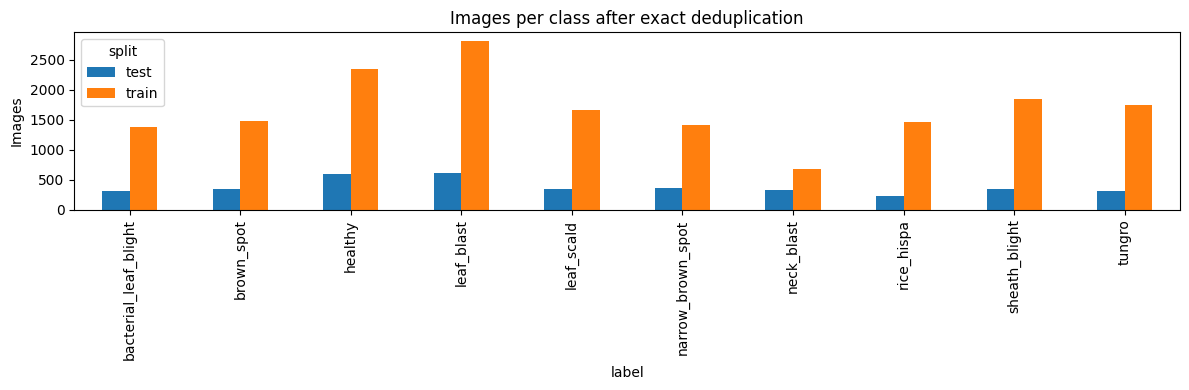

In [3]:
manifest_path = ARTIFACTS / 'dataset_manifest.csv'
manifest = pd.read_csv(manifest_path) if manifest_path.exists() else audit_dataset()
display(manifest.groupby(['split','status']).size().rename('images').reset_index())
display(manifest[manifest.status.eq('excluded')][['path','label','reason']].head(10))
usable = manifest[manifest.status.eq('included')].copy()
assert not usable.pixel_sha256.duplicated().any()
counts = usable.groupby(['label','split']).size().unstack(fill_value=0)
display(counts)
counts.plot.bar(figsize=(12,4), title='Images per class after exact deduplication')
plt.ylabel('Images'); plt.tight_layout(); plt.show()

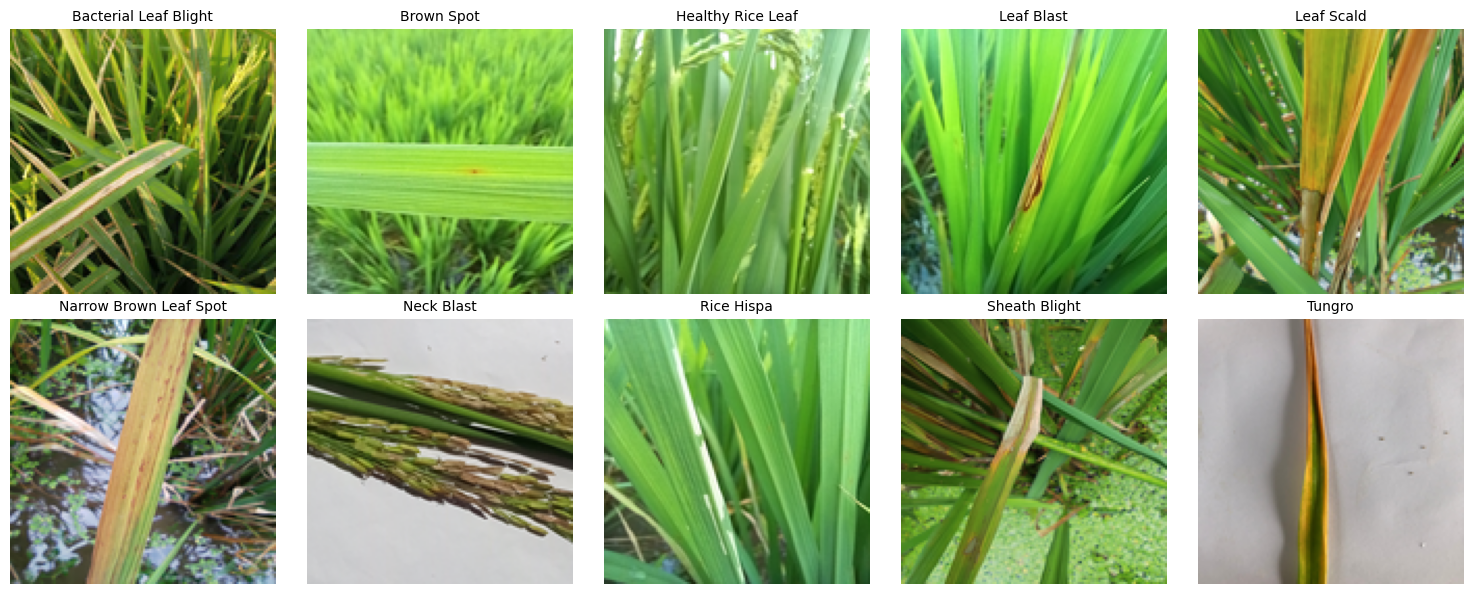

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15,6))
for ax, label in zip(axes.flat, CLASSES):
    path = ROOT / usable[usable.label.eq(label)].iloc[0].path
    ax.imshow(preprocess_image(path)); ax.set_title(CLASSES[label][0], fontsize=10); ax.axis('off')
plt.tight_layout(); plt.show()

## 4. เตรียมภาพและสกัดคุณลักษณะ
แปลง RGB, resize ทั้งเฟรมเป็น 128 × 128 (อัตราส่วนภาพอาจเปลี่ยน) โดยไม่ segment หรือ crop จากนั้นสกัด HSV histogram แบบ global และ 2×2 จำนวน 180 ค่า ร่วมกับค่าเฉลี่ย/ส่วนเบี่ยงเบน RGB และ histogram ทิศทางขอบในกริด 4×4 อีก 224 ค่า รวม **404 features**

เลือกสีและ texture เพราะอธิบายได้ ใช้ CPU และไฟล์โมเดลร่วมกับ Gradio ได้ง่าย แต่รายละเอียดรอยโรคเล็กอาจหายเมื่อ resize พื้นหลัง/แสงอาจรบกวน ใช้ `StandardScaler` ใน pipeline ซึ่ง fit เฉพาะข้อมูลฝึก และใช้ preprocessing ฟังก์ชันเดียวกับแอป

Feature shape: (404,) Finite: True
def image_to_features(image):
    return features_from_processed(preprocess_image(image))



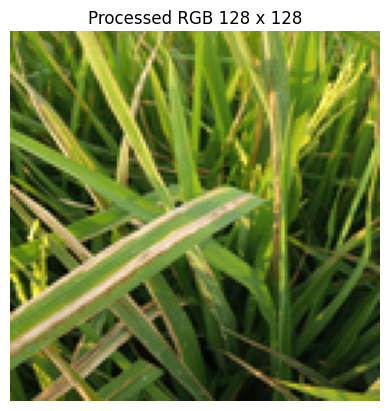

In [5]:
sample_path = ROOT / usable.iloc[0].path
features = image_to_features(sample_path)
print('Feature shape:', features.shape, 'Finite:', np.isfinite(features).all())
print(inspect.getsource(image_to_features))
plt.imshow(preprocess_image(sample_path)); plt.title('Processed RGB 128 x 128'); plt.axis('off'); plt.show()

## 5. แบ่งชุด เลือกโมเดล ฝึกและบันทึก
เก็บ test เดิมไว้ประเมินครั้งสุดท้าย ไม่ใช้ test เลือก hyperparameter แบ่ง eligible train เป็น fit/validation 80/20 แบบ stratified ด้วย seed 42 เลือก RBF SVM ระหว่าง C=1 และ C=10 จาก **validation macro F1** แล้วฝึกใหม่ด้วย eligible train ทั้งหมด

SVM เหมาะเป็น baseline ของข้อมูลคุณลักษณะสี/texture ใช้ class_weight=balanced ลดผลจากจำนวนคลาสไม่เท่ากัน เปิด probability=True ในโมเดลสุดท้ายเพื่อแสดงคะแนนในแอป เลือก label ด้วย argmax(predict_proba) ทั้งในรายงานและแอป เพราะ SVC.predict อาจให้ผลต่างจาก probability argmax

ไฟล์ joblib เก็บ scaler และ SVM พร้อม feature version และ metadata; โหลดกลับตรวจค่า probability เท่าเดิมในสคริปต์ฝึก ตั้ง RETRAIN=True เพื่อรันขั้นตอนฝึกทั้งหมดใหม่ ซึ่งอาจใช้เวลาหลายนาที

In [6]:
# Show the exact training implementation used by this project.
print(inspect.getsource(train))

def train():
    print("1/5 Auditing images and exact duplicates...", flush=True)
    manifest = audit_dataset()
    usable = manifest[manifest.status.eq("included")].reset_index(drop=True)
    print(f"Included {len(usable)} / {len(manifest)} images", flush=True)
    print("2/5 Extracting 404 color and texture features...", flush=True)
    with ThreadPoolExecutor(max_workers=4) as pool:
        features = []
        for i, feature in enumerate(pool.map(image_to_features, [ROOT / p for p in usable.path]), 1):
            features.append(feature)
            if i % 2000 == 0:
                print(f"Extracted {i}/{len(usable)} images", flush=True)
        X = np.asarray(features)
    y = usable.label.to_numpy()
    train_idx = np.flatnonzero(usable.split.eq("train"))
    test_idx = np.flatnonzero(usable.split.eq("test"))
    fit_idx, val_idx = train_test_split(train_idx, test_size=0.2, stratify=y[train_idx], random_state=SEED)
    usable["development_split"] = "test"
    usable.loc[fit_i

In [7]:
RETRAIN = False
if RETRAIN or not MODEL_PATH.exists():
    metrics = train()
else:
    metrics = json.loads((ARTIFACTS / 'metrics.json').read_text(encoding='utf-8'))
    print('Review mode: loading the model actually trained by train_model.py; no retraining in this cell.')
bundle = joblib.load(MODEL_PATH)
model = bundle['model']
display(pd.DataFrame(metrics['candidates']))
print('Selected C:', metrics['best_C'])
print('Saved model:', MODEL_PATH.relative_to(ROOT))
display(model)
split_manifest = pd.read_csv(ARTIFACTS / 'split_manifest.csv')
display(split_manifest.groupby(['label','development_split']).size().unstack(fill_value=0))
assert not split_manifest.pixel_sha256.duplicated().any()

Review mode: loading the model actually trained by train_model.py; no retraining in this cell.


,C,validation_macro_f1
0,1.0,0.889447
1,10.0,0.951087


Selected C: 10.0
Saved model: rice_leaf_app\models\rice_classifier.joblib


,steps,"[('standardscaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,10.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


development_split,fit,test,validation
label,,,
bacterial_leaf_blight,1109,318,277
brown_spot,1184,349,296
healthy,1876,603,469
leaf_blast,2255,605,564
leaf_scald,1336,344,334
narrow_brown_spot,1133,363,283
neck_blast,542,322,136
rice_hispa,1169,225,292
sheath_blight,1482,353,371


## 6. ประเมินบน test และเปรียบเทียบระหว่างคลาส
คำนวณผลใหม่จากภาพ test ที่ผ่าน audit ด้วยโมเดลบันทึกจริง และตรวจว่าตรงกับรายงาน

- Accuracy: สัดส่วนภาพทั้งหมดที่ทำนายถูก
- Precision รายคลาส: ในภาพที่ทำนายเป็นคลาสนี้ มีภาพจริงคลาสนี้กี่ส่วน
- Recall รายคลาส: ในภาพจริงคลาสนี้ โมเดลทำนายพบกี่ส่วน
- F1: harmonic mean ของ precision และ recall
- **Macro F1 เป็นเมตริกหลัก**: ให้ทุกคลาสน้ำหนักเท่ากัน
- Weighted F1: เฉลี่ย F1 ตามจำนวนภาพจริงในแต่ละคลาส

ไม่มีการเปลี่ยนโมเดลตามคะแนน test ในขั้นตอนนี้

Accuracy: 0.8850 | Macro F1: 0.8870 | Weighted F1: 0.8840


,precision,recall,f1-score,support
bacterial_leaf_blight,1.000000,0.996855,0.998425,318.0
brown_spot,0.947205,0.873926,0.909091,349.0
healthy,0.838661,0.913765,0.874603,603.0
leaf_blast,0.723288,0.872727,0.791011,605.0
leaf_scald,0.966361,0.918605,0.941878,344.0
narrow_brown_spot,0.944606,0.892562,0.917847,363.0
neck_blast,0.981481,0.987578,0.984520,322.0
rice_hispa,0.889706,0.537778,0.670360,225.0
sheath_blight,0.826625,0.756374,0.789941,353.0
tungro,0.987220,0.996774,0.991974,310.0


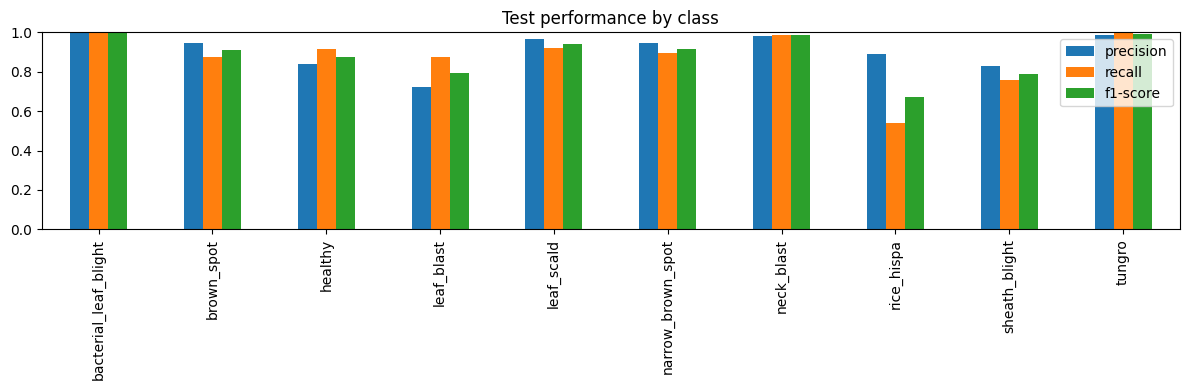

In [8]:
test_rows = split_manifest[split_manifest.split.eq('test')].copy()
with ThreadPoolExecutor(max_workers=4) as pool:
    X_test = np.asarray(list(pool.map(image_to_features, [ROOT / p for p in test_rows.path])))
y_test = test_rows.label.to_numpy()
probabilities = model.predict_proba(X_test)
y_pred = model.classes_[probabilities.argmax(axis=1)]
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
np.testing.assert_allclose([accuracy, macro_f1, weighted_f1], [metrics['accuracy'], metrics['macro_f1'], metrics['weighted_f1']])
print(f'Accuracy: {accuracy:.4f} | Macro F1: {macro_f1:.4f} | Weighted F1: {weighted_f1:.4f}')
report = classification_report(y_test, y_pred, labels=list(CLASSES), output_dict=True, zero_division=0)
per_class = pd.DataFrame({k:report[k] for k in CLASSES}).T
display(per_class)
per_class[['precision','recall','f1-score']].plot.bar(figsize=(12,4), ylim=(0,1), title='Test performance by class')
plt.tight_layout(); plt.show()

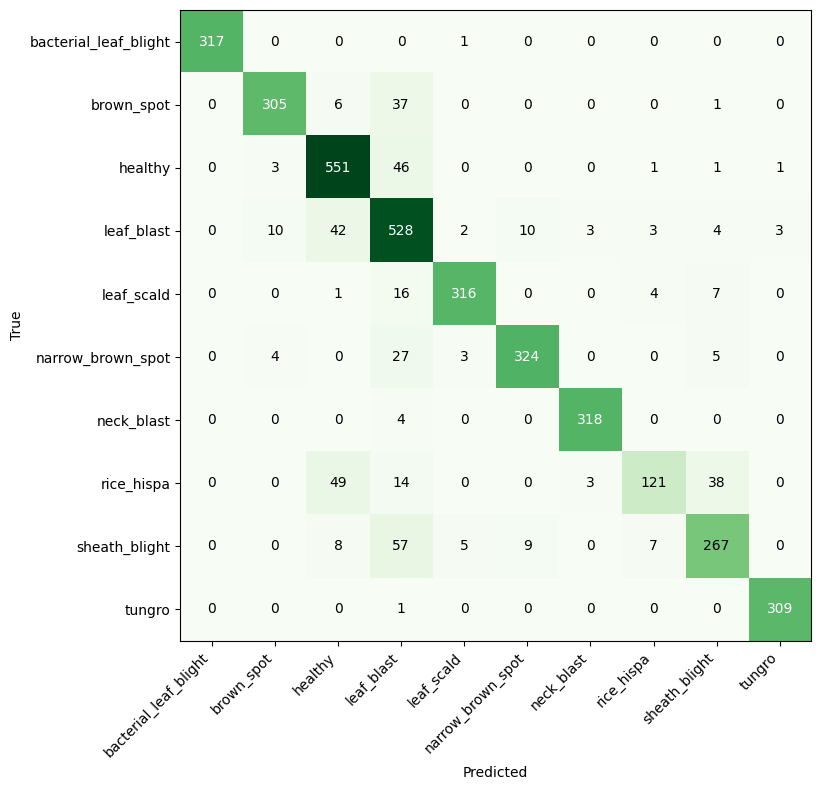

คลาส F1 สูงสุด: **bacterial_leaf_blight (0.998)**; ต่ำสุด: **rice_hispa (0.670)**. คู่สับสนแบบมีทิศทางมากที่สุด: **sheath_blight → leaf_blast จำนวน 57 ภาพ**. คะแนนต่ำหมายถึงยังแยกลักษณะคลาสได้ไม่ดี ต้องพิจารณาภาพผิดร่วมด้วยก่อนสรุปสาเหตุ

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=list(CLASSES))
np.testing.assert_array_equal(cm, metrics['confusion_matrix'])
fig, ax = plt.subplots(figsize=(10,8))
ax.imshow(cm, cmap='Greens')
ax.set(xticks=range(10), yticks=range(10), xticklabels=list(CLASSES), yticklabels=list(CLASSES), xlabel='Predicted', ylabel='True')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
for i in range(10):
    for j in range(10):
        ax.text(j,i,str(cm[i,j]),ha='center',va='center',color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout(); plt.show()
best, worst = per_class['f1-score'].idxmax(), per_class['f1-score'].idxmin()
off_diagonal = cm.copy(); np.fill_diagonal(off_diagonal,0)
i,j = np.unravel_index(off_diagonal.argmax(), off_diagonal.shape)
display(Markdown(f'คลาส F1 สูงสุด: **{best} ({per_class.loc[best,"f1-score"]:.3f})**; ต่ำสุด: **{worst} ({per_class.loc[worst,"f1-score"]:.3f})**. คู่สับสนแบบมีทิศทางมากที่สุด: **{list(CLASSES)[i]} → {list(CLASSES)[j]} จำนวน {cm[i,j]} ภาพ**. คะแนนต่ำหมายถึงยังแยกลักษณะคลาสได้ไม่ดี ต้องพิจารณาภาพผิดร่วมด้วยก่อนสรุปสาเหตุ'))

## 7. ตัวอย่างผลทำนายและวิเคราะห์ข้อผิดพลาด
แสดงทั้งภาพถูกและภาพผิด โดยระบุคลาสจริง คลาสทำนาย และคะแนนสูงสุด ไม่เลือกเฉพาะผลดี สาเหตุที่อาจทำให้สับสน ได้แก่สี/texture คล้ายกัน แสง พื้นหลัง และรอยโรคเล็กหลัง resize ซึ่งเป็นสมมติฐานที่ต้องตรวจเพิ่ม ไม่ใช่ข้อสรุปเชิงสาเหตุ

ข้อจำกัดที่สำคัญ: ไม่ทราบ plant/source-image ID ของ dataset จึงยังอาจมี augmented relatives ข้าม train/test และคะแนนอาจสูงกว่าการนำไปใช้ในแปลงใหม่ แนะนำสร้าง test จากแปลง/ต้นใหม่และแยกก่อน augmentation ในงานต่อไป

,path,label,predicted,probability,correct
81,Rice_Leaf_Diease/Rice_Leaf_Diease/test/bacteri...,bacterial_leaf_blight,leaf_scald,0.597218,False
318,Rice_Leaf_Diease/Rice_Leaf_Diease/test/brown_s...,brown_spot,healthy,0.574272,False
319,Rice_Leaf_Diease/Rice_Leaf_Diease/test/brown_s...,brown_spot,healthy,0.576367,False
320,Rice_Leaf_Diease/Rice_Leaf_Diease/test/brown_s...,brown_spot,healthy,0.512365,False
321,Rice_Leaf_Diease/Rice_Leaf_Diease/test/brown_s...,brown_spot,leaf_blast,0.798807,False
322,Rice_Leaf_Diease/Rice_Leaf_Diease/test/brown_s...,brown_spot,leaf_blast,0.805580,False
329,Rice_Leaf_Diease/Rice_Leaf_Diease/test/brown_s...,brown_spot,leaf_blast,0.968859,False
332,Rice_Leaf_Diease/Rice_Leaf_Diease/test/brown_s...,brown_spot,leaf_blast,0.667873,False
337,Rice_Leaf_Diease/Rice_Leaf_Diease/test/brown_s...,brown_spot,leaf_blast,0.719361,False
381,Rice_Leaf_Diease/Rice_Leaf_Diease/test/brown_s...,brown_spot,leaf_blast,0.930089,False


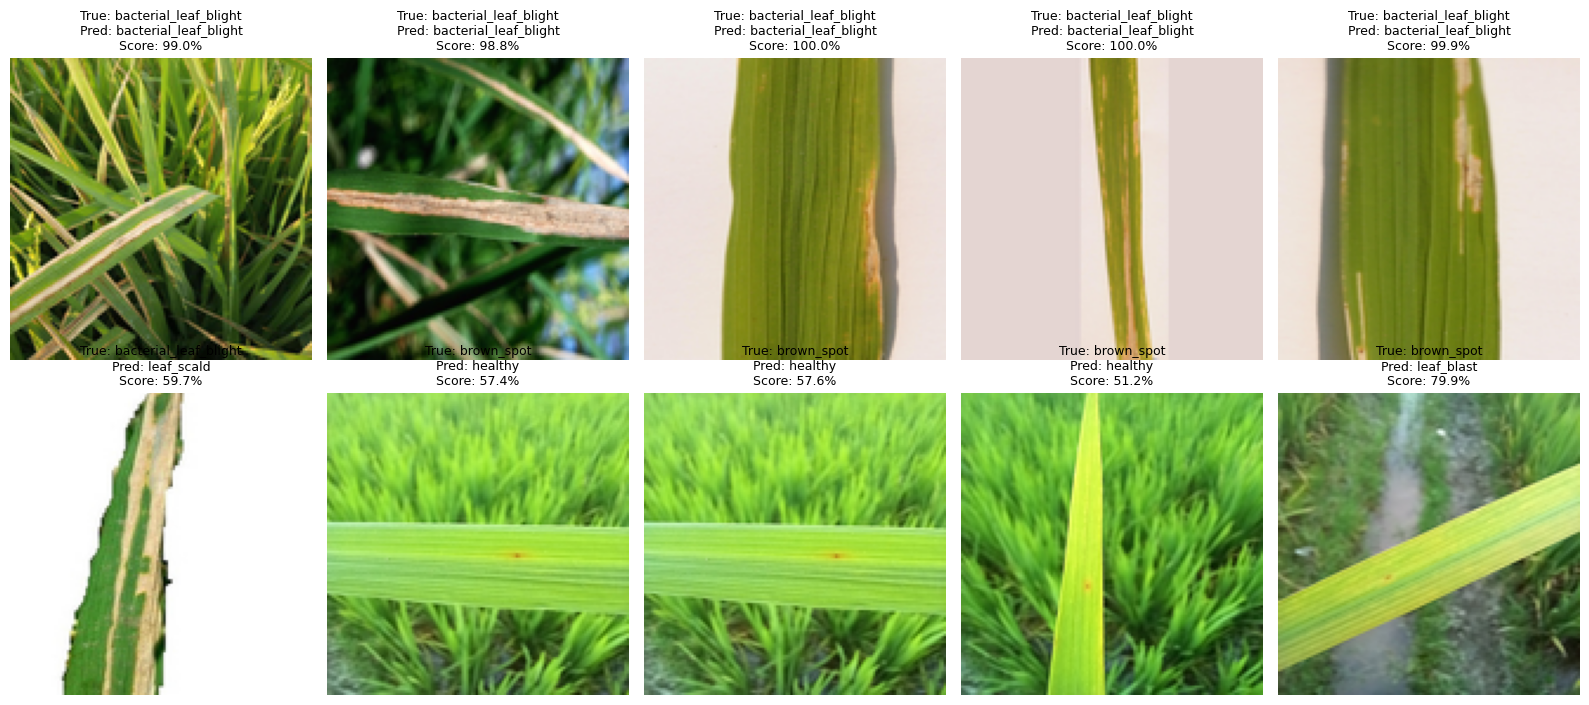

In [10]:
results = test_rows[['path','label']].copy()
results['predicted'] = y_pred
results['probability'] = probabilities.max(axis=1)
results['correct'] = y_test == y_pred
display(results[~results.correct].head(20))
examples = pd.concat([results[results.correct].head(5), results[~results.correct].head(5)])
fig, axes = plt.subplots(2,5,figsize=(16,7))
for ax in axes.flat: ax.axis('off')
for ax, (_,row) in zip(axes.flat, examples.iterrows()):
    ax.imshow(preprocess_image(ROOT / row.path))
    ax.set_title(f'True: {row.label}\nPred: {row.predicted}\nScore: {row.probability:.1%}',fontsize=9)
plt.tight_layout(); plt.show()

## 8. ใช้โมเดลในแอปและตรวจความสอดคล้อง
Gradio รับภาพ → preprocessing ร่วม → scaler + SVM ที่บันทึกไว้ → คะแนน 10 คลาสและภาพ RGB ที่เตรียมแล้ว มีแท็บเปรียบเทียบสองคลาสและผลประเมิน

รันแอปจาก project root: `python app.py` แล้วเปิด http://127.0.0.1:7861
ไฟล์ deploy เตรียมไว้และเพิ่มรายชื่อผู้จัดทำใน README แล้ว; GitHub: [https://github.com/NongkaiOne/Rice-Leaf-Disease-Classification-and-MPG-Regression](https://github.com/NongkaiOne/Rice-Leaf-Disease-Classification-and-MPG-Regression) ส่วน public URL ของแอปยังรอ deploy ดู `STATUS.md`

### ผลจำแนก: Bacterial Leaf Blight · ขอบใบแห้ง
คะแนนโมเดล **99.0%**

คะแนนเป็นค่าประมาณจากโมเดล ไม่ใช่ความแน่นอนว่าภาพมีโรคนั้น

,Class,Score (%)
0,Bacterial Leaf Blight · ขอบใบแห้ง,99.04
1,Leaf Blast · ไหม้ใบ,0.66
2,Sheath Blight · กาบใบแห้ง,0.08
3,Healthy Rice Leaf · ใบข้าวปกติ,0.07
4,Narrow Brown Leaf Spot · ใบขีดสีน้ำตาล,0.05
5,Rice Hispa · ใบเสียหายจากแมลงดำหนาม,0.03
6,Leaf Scald · ใบลวก,0.02
7,Brown Spot · ใบจุดสีน้ำตาล,0.02
8,Tungro · ทังโกร,0.02
9,Neck Blast · ไหม้คอรวง,0.02


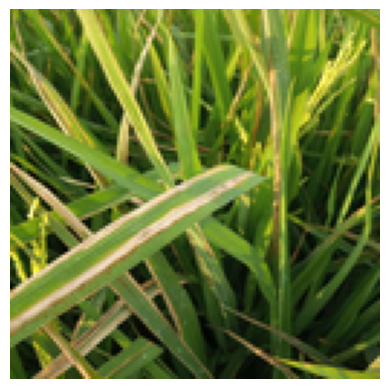

C:\Rice Leaf Diseases Detection\.runtime\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PASS: split integrity, evaluation consistency, saved model, 10-class inference, preprocessing parity, upload formats, empty input, Gradio construction


In [11]:
from rice_leaf_app.inference import get_predictor
scores, preview, summary, rows = get_predictor().predict(ROOT / test_rows.iloc[0].path)
display(Markdown(summary)); display(pd.DataFrame(rows, columns=['Class','Score (%)']))
np.testing.assert_allclose(max(scores.values()), probabilities[0].max())
plt.imshow(preview); plt.axis('off'); plt.show()
from rice_leaf_app.verify import verify
verify()